In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , hamming_loss , accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

In [74]:
df = pd.read_csv(r"C:\Users\NPC\Downloads\CompanyDocs_balanced_.csv")
df.head()

,file_name,page_number,has_table,has_index,has_graph,has_infographics
0,investor ppt reliance,1,0,1,0,1
1,investor ppt reliance,2,0,1,1,1
2,investor ppt reliance,3,1,0,1,1
3,investor ppt reliance,4,1,1,1,0
4,investor ppt reliance,5,0,0,0,0


In [75]:
df.shape

(815, 6)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   file_name         815 non-null    object
 1   page_number       815 non-null    int64 
 2   has_table         815 non-null    int64 
 3   has_index         815 non-null    int64 
 4   has_graph         815 non-null    int64 
 5   has_infographics  815 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 38.3+ KB


In [77]:
df.drop(columns='page_number', inplace=True)

In [78]:
df.describe()

,has_table,has_index,has_graph,has_infographics
count,815.000000,815.000000,815.000000,815.000000
mean,0.593865,0.577914,0.615951,0.499387
std,0.491412,0.494195,0.486668,0.500307
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [79]:
print(df[["has_table","has_index","has_graph","has_infographics"]].sum())

has_table           484
has_index           471
has_graph           502
has_infographics    407
dtype: int64


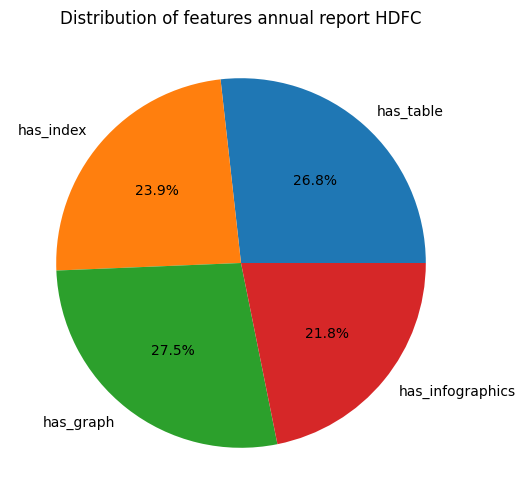

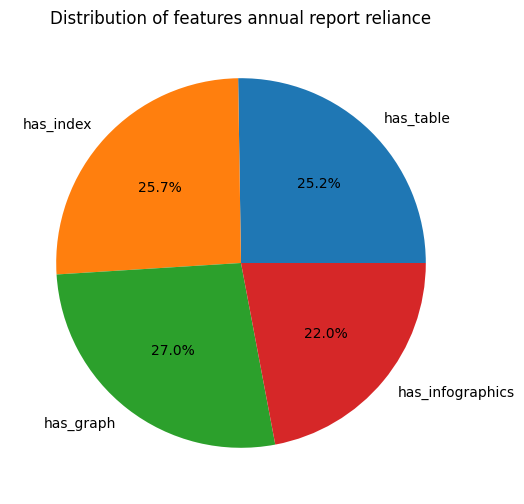

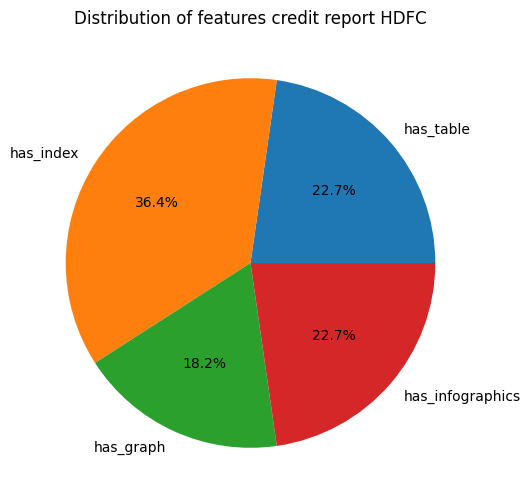

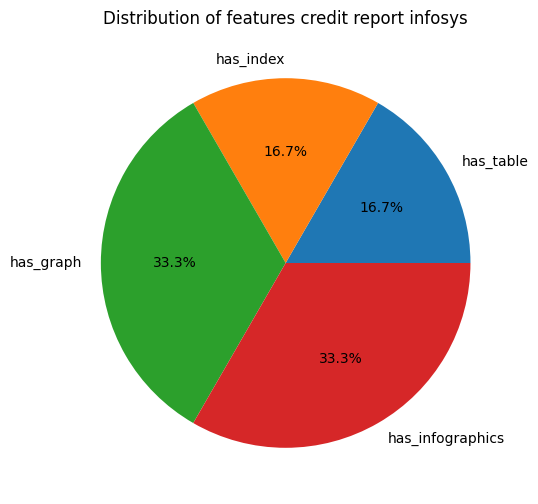

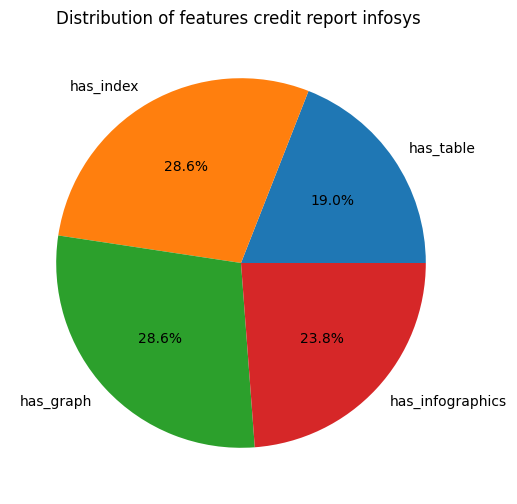

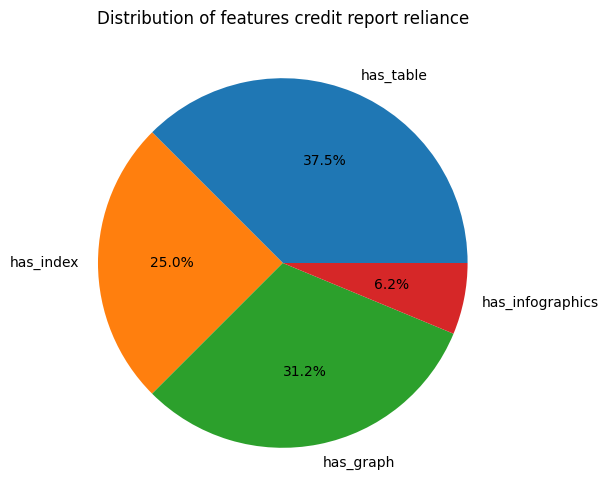

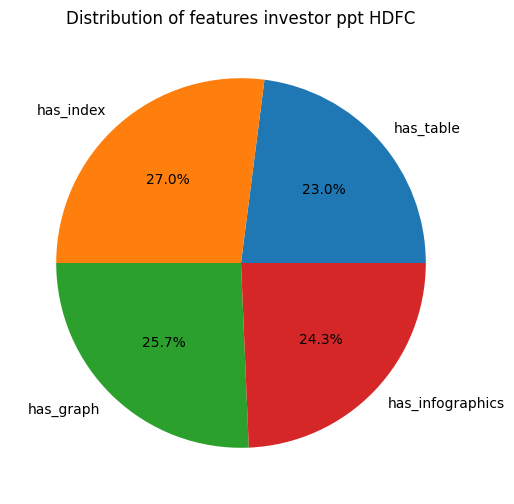

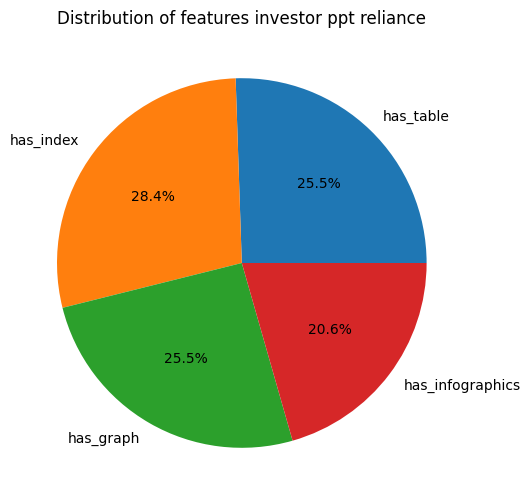

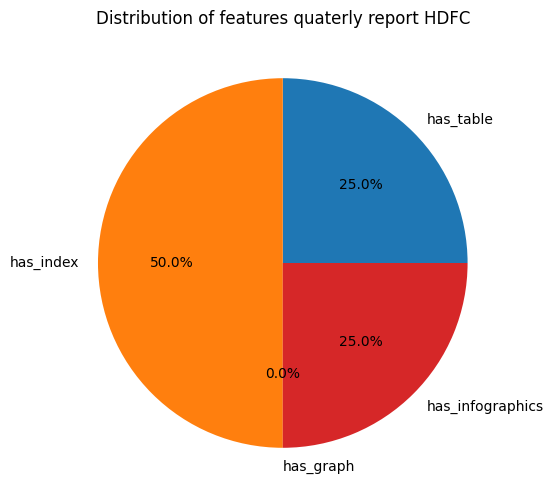

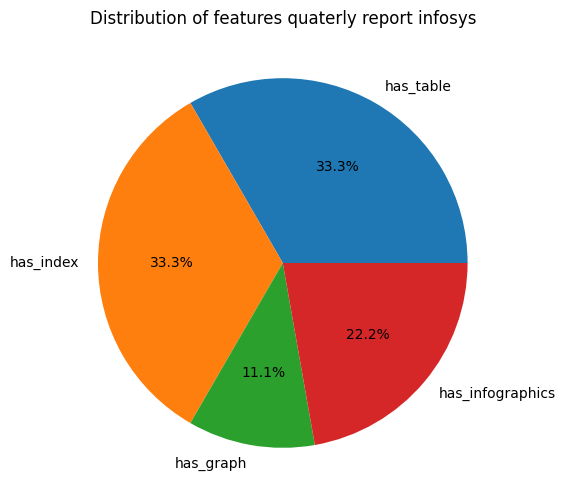

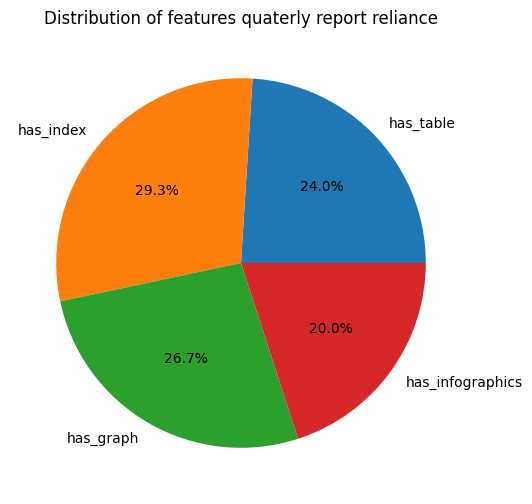

In [80]:
group_cols = "file_name"
cols = ["has_table", "has_index", "has_graph", "has_infographics"]

for doc, group in df.groupby(group_cols):
    counts = group[cols].sum()

    plt.figure(figsize=(6,6))
    plt.pie(counts , labels= counts.index , autopct='%1.1f%%')
    plt.title(f"Distribution of features {doc}")
    plt.show()

In [81]:
X = df['file_name']  #features
y = df[['has_table' , 'has_index' , 'has_graph' , 'has_infographics']]  #labels



In [82]:
X_train , X_test , y_train , y_test = train_test_split(X,y, random_state=42 , test_size=0.2 , stratify=y )

In [83]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

In [84]:
for model_name, model in models.items():
    print(f"{model_name}")
    
    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    classification = OneVsRestClassifier(model)
    classification.fit(X_train_tfidf , y_train)

    y_pred = classification.predict(X_test_tfidf.toarray())
    
    print("Accuracy Score: " , accuracy_score(y_test , y_pred))
    print("Hamming Loss:", hamming_loss(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
Accuracy Score:  0.08588957055214724
Hamming Loss: 0.4447852760736196
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.95      0.73        98
           1       0.58      1.00      0.73        94
           2       0.61      1.00      0.76       100
           3       0.46      0.56      0.50        81

   micro avg       0.57      0.89      0.70       373
   macro avg       0.56      0.88      0.68       373
weighted avg       0.57      0.89      0.69       373
 samples avg       0.57      0.88      0.67       373

Random Forest
Accuracy Score:  0.06748466257668712
Hamming Loss: 0.45245398773006135
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.95      0.73        98
           1       0.58      1.00      0.73        94
           2       0.60      0.88      0.72       100
           3       0.48      0.83      0.61        81

   micro avg    